In [ ]:
# Removed opencv-contrib-python from here to manage installation order explicitly.

In [ ]:
!pip uninstall -y opencv-python opencv-contrib-python
!pip install ultralytics kagglehub timm
!pip install opencv-contrib-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 78.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 824.0/824.0 kB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.2/79.2 MB 17.1 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import torch
import torch.nn as nn
import numpy as np
from ultralytics import YOLO
import kagglehub

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
path = kagglehub.dataset_download("lywang777/urpc2020")

print("Dataset Path:", path)

Using Colab cache for faster access to the 'urpc2020' dataset.
Dataset Path: /kaggle/input/urpc2020


In [ ]:
import yaml
import os

yaml_path = os.path.join(path, "URPC2020/data.yaml")

with open(yaml_path) as f:
    data = yaml.safe_load(f)

base_dataset_path = os.path.join(path, "URPC2020")
data['path'] = base_dataset_path
data['train'] = os.path.join(base_dataset_path, "train/images")
data['val'] = os.path.join(base_dataset_path, "valid/images")
data['test'] = os.path.join(base_dataset_path, "test/images")

with open("data.yaml", "w") as f:
    yaml.dump(data, f)

In [ ]:
def preprocess_image(img):
    wb = cv2.xphoto.createSimpleWB()
    img = wb.balanceWhite(img)


    img = cv2.GaussianBlur(img, (5,5), 0)


    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l,a,b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)

    img = cv2.merge((cl,a,b))
    img = cv2.cvtColor(img, cv2.COLOR_LAB2BGR)

    return img

In [ ]:
import os
import cv2
from tqdm.notebook import tqdm

base_path = os.path.join(path, "URPC2020")

def process_folder(folder):
    print(f"Processing images in: {folder}")
    for img_name in tqdm(os.listdir(folder), desc=f"Processing {os.path.basename(folder)}"):
        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path)

        if img is None:

            continue

        processed = preprocess_image(img)
        cv2.imwrite(img_path, processed)

for split in ["train", "valid", "test"]:
    process_folder(os.path.join(base_path, split, "images"))

print("Preprocessing Done ✅")

Processing images in: /kaggle/input/urpc2020/URPC2020/train/images


Processing images:   0%|          | 0/5543 [00:00<?, ?it/s]

Processing images in: /kaggle/input/urpc2020/URPC2020/valid/images


Processing images:   0%|          | 0/1200 [00:00<?, ?it/s]

Processing images in: /kaggle/input/urpc2020/URPC2020/test/images


Processing images:   0%|          | 0/800 [00:00<?, ?it/s]

Preprocessing Done ✅


In [ ]:
class ECAModule(nn.Module):
    def __init__(self, channels, k_size=3):
        super(ECAModule, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=k_size, padding=(k_size-1)//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        y = self.avg_pool(x)
        y = self.conv(y.squeeze(-1).transpose(-1, -2))
        y = self.sigmoid(y).transpose(-1, -2).unsqueeze(-1)
        return x * y.expand_as(x)

In [ ]:
import timm

class MobileNetV3_ECA(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model('mobilenetv3_small_100', pretrained=True, features_only=True)
        self.eca = ECAModule(576)

    def forward(self, x):
        features = self.backbone(x)
        x = features[-1]
        x = self.eca(x)
        return x

In [ ]:
model = YOLO("yolov8n.pt")

In [ ]:
model.train(
    data="data.yaml",
    epochs=4,
    imgsz=640,
    batch=16
)

Ultralytics 8.4.24 🚀 Python-3.12.13 torch-2.9.0+cpu CPU (AMD EPYC 7B13)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=4, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pret

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e6fe64e16a0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [ ]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.24 🚀 Python-3.12.13 torch-2.9.0+cpu CPU (AMD EPYC 7B13)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 691.5±329.5 MB/s, size: 342.5 KB)
val: Scanning /kaggle/input/urpc2020/URPC2020/valid/labels... 1200 images, 47 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1200/1200 2.1Kit/s 0.6s
WARNING ⚠️ val: Cache directory /kaggle/input/urpc2020/URPC2020/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 75/75 1.3it/s 58.1s
                   all       1200       9390      0.694      0.551      0.607      0.326
           holothurian        255        461      0.585      0.406      0.439      0.237
               echinus        816       4233        0.7      0.788      0.791      0.398
               scallop        315       3196       0.73      0.407      0.531      0.299
              starfish        55

In [ ]:
results = model.predict(
    source=os.path.join(base_path, "test/images"),
    save=True,
    conf=0.25
)


image 1/800 /kaggle/input/urpc2020/URPC2020/test/images/000001.jpg: 384x640 9 echinuss, 1 starfish, 42.2ms
image 2/800 /kaggle/input/urpc2020/URPC2020/test/images/000002.jpg: 384x640 10 echinuss, 1 starfish, 31.6ms
image 3/800 /kaggle/input/urpc2020/URPC2020/test/images/000003.jpg: 384x640 3 holothurians, 1 echinus, 62.1ms
image 4/800 /kaggle/input/urpc2020/URPC2020/test/images/000004.jpg: 384x640 1 holothurian, 1 echinus, 1 starfish, 66.7ms
image 5/800 /kaggle/input/urpc2020/URPC2020/test/images/000005.jpg: 384x640 1 holothurian, 6 echinuss, 24.3ms
image 6/800 /kaggle/input/urpc2020/URPC2020/test/images/000006.jpg: 384x640 1 holothurian, 4 echinuss, 1 starfish, 57.1ms
image 7/800 /kaggle/input/urpc2020/URPC2020/test/images/000007.jpg: 384x640 1 echinus, 1 starfish, 67.4ms
image 8/800 /kaggle/input/urpc2020/URPC2020/test/images/000008.jpg: 384x640 1 holothurian, 4 scallops, 1 starfish, 24.3ms
image 9/800 /kaggle/input/urpc2020/URPC2020/test/images/000009.jpg: 384x640 1 holothurian, 59

In [ ]:
import time

img = os.path.join(base_path, "test/images")
start = time.time()
model.predict(img)
end = time.time()

print("FPS:", 1/(end-start))


image 1/800 /kaggle/input/urpc2020/URPC2020/test/images/000001.jpg: 384x640 9 echinuss, 1 starfish, 25.0ms
image 2/800 /kaggle/input/urpc2020/URPC2020/test/images/000002.jpg: 384x640 10 echinuss, 1 starfish, 25.1ms
image 3/800 /kaggle/input/urpc2020/URPC2020/test/images/000003.jpg: 384x640 3 holothurians, 1 echinus, 72.6ms
image 4/800 /kaggle/input/urpc2020/URPC2020/test/images/000004.jpg: 384x640 1 holothurian, 1 echinus, 1 starfish, 25.3ms
image 5/800 /kaggle/input/urpc2020/URPC2020/test/images/000005.jpg: 384x640 1 holothurian, 6 echinuss, 71.7ms
image 6/800 /kaggle/input/urpc2020/URPC2020/test/images/000006.jpg: 384x640 1 holothurian, 4 echinuss, 1 starfish, 75.0ms
image 7/800 /kaggle/input/urpc2020/URPC2020/test/images/000007.jpg: 384x640 1 echinus, 1 starfish, 24.2ms
image 8/800 /kaggle/input/urpc2020/URPC2020/test/images/000008.jpg: 384x640 1 holothurian, 4 scallops, 1 starfish, 74.3ms
image 9/800 /kaggle/input/urpc2020/URPC2020/test/images/000009.jpg: 384x640 1 holothurian, 73


image 1/1 /kaggle/input/urpc2020/URPC2020/test/images/000129.jpg: 384x640 1 holothurian, 1 echinus, 1 scallop, 26.0ms
Speed: 1.4ms preprocess, 26.0ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /kaggle/input/urpc2020/URPC2020/test/images/000798.jpg: 384x640 13 echinuss, 13 starfishs, 24.8ms
Speed: 1.3ms preprocess, 24.8ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /kaggle/input/urpc2020/URPC2020/test/images/000294.jpg: 384x640 1 holothurian, 23 scallops, 25.5ms
Speed: 1.5ms preprocess, 25.5ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /kaggle/input/urpc2020/URPC2020/test/images/000386.jpg: 384x640 8 scallops, 1 starfish, 33.9ms
Speed: 1.4ms preprocess, 33.9ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)


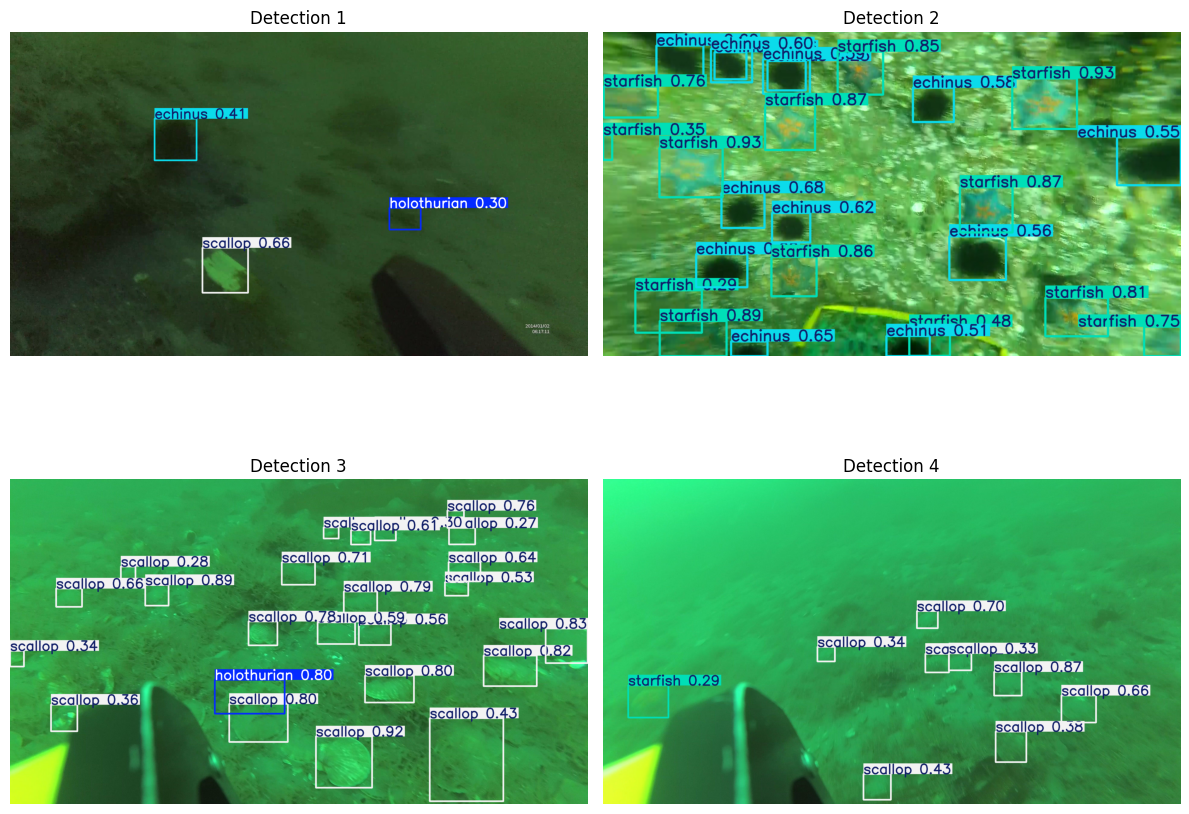

In [ ]:
import os
import random
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO


model = YOLO("runs/detect/train/weights/best.pt")


test_path = os.path.join(base_path, "test/images")


image_list = random.sample(os.listdir(test_path), 4)

plt.figure(figsize=(12,10))

for i, img_name in enumerate(image_list):
    img_path = os.path.join(test_path, img_name)


    results = model.predict(
        source=img_path,
        conf=0.25,
        save=False
    )


    plotted_img = results[0].plot()


    plotted_img = cv2.cvtColor(plotted_img, cv2.COLOR_BGR2RGB)


    plt.subplot(2, 2, i+1)
    plt.imshow(plotted_img)
    plt.title(f"Detection {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import shutil
import os

source_path = "runs/detect/train/weights/best.pt"
destination_path = "best_yolov8n_model.pt"

if os.path.exists(source_path):
    shutil.copy(source_path, destination_path)
    print(f"Model copied to: {destination_path}")
    print("You can now download 'best_yolov8n_model.pt' from the Colab file browser.")
else:
    print(f"Error: Model file not found at {source_path}")

Error: Model file not found at runs/detect/train/weights/best.pt
